<a href="https://colab.research.google.com/github/HammadN98/Pos-Inteligencia-Artificial-e-Computacional/blob/main/Topicos-Especiais-IA/Topicos_Especiais_Relatorio_2_ES119826.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Cultivares de Tomate



In [2]:
# Bibliotecas básicas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-processamento e seleção de features
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

# Divisão de dados e validação cruzada
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV

# Modelos de regressão
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

# Métricas de avaliação
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    make_scorer
)

# Estatísticas
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [3]:
url_dados = "https://raw.githubusercontent.com/HammadN98/Pos-Inteligencia-Artificial-e-Computacional/refs/heads/main/Topicos-Especiais-IA/dados/dataset_problema2.csv"
dados = pd.read_csv(url_dados)


In [4]:
dados.columns

Index(['id', 'NDVI_d28', 'SAVI_d28', 'GNDVI_d28', 'MCARI1_d28', 'SR_d28',
       'NDVI_d01', 'SAVI_d01', 'GNDVI_d01', 'MCARI1_d01', 'SR_d01', 'NDVI_d04',
       'SAVI_d04', 'GNDVI_d04', 'MCARI1_d04', 'SR_d04', 'NDVI_d08', 'SAVI_d08',
       'GNDVI_d08', 'MCARI1_d08', 'SR_d08', 'Severidade'],
      dtype='object')

## Pre-Processamento

In [5]:
dados.describe()

,id,NDVI_d28,SAVI_d28,GNDVI_d28,MCARI1_d28,SR_d28,NDVI_d01,SAVI_d01,GNDVI_d01,MCARI1_d01,...,SAVI_d04,GNDVI_d04,MCARI1_d04,SR_d04,NDVI_d08,SAVI_d08,GNDVI_d08,MCARI1_d08,SR_d08,Severidade
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,...,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,66.500000,0.780023,1.169990,0.674060,16462.800069,9.124822,0.754009,1.130988,0.699398,27444.185075,...,1.092219,0.660012,14519.771222,6.762840,0.719198,1.078754,0.657604,15001.133221,6.479522,45.560606
std,38.249183,0.035999,0.053999,0.034849,1709.098541,1.433713,0.032205,0.048308,0.030261,3711.784699,...,0.043631,0.028366,2654.859976,0.909740,0.033993,0.050991,0.028864,2563.017213,1.153460,23.051651
min,1.000000,0.649085,0.973586,0.556922,11005.355800,4.789961,0.635930,0.953869,0.592644,18122.404820,...,0.964381,0.552340,9431.856566,4.653617,0.655962,0.983908,0.582567,11463.913340,4.902359,0.000000
25%,33.750000,0.772210,1.158270,0.669149,15640.851240,8.573545,0.744248,1.116344,0.695318,24887.192403,...,1.065336,0.650594,12726.575570,6.150417,0.694633,1.041907,0.642005,13312.951140,5.712593,36.907500
50%,66.500000,0.788128,1.182145,0.680441,16762.631610,9.323441,0.761036,1.141527,0.705402,27679.685570,...,1.097308,0.665373,14091.257330,6.728679,0.712214,1.068278,0.651413,14295.935300,6.146371,53.890000
75%,99.250000,0.803054,1.204534,0.694304,17570.790822,10.112440,0.773866,1.160773,0.714582,30054.630575,...,1.119825,0.676848,15864.872955,7.312529,0.728163,1.092204,0.671040,15673.598085,6.559074,62.717500
max,132.000000,0.827867,1.241756,0.719607,19574.211170,11.798039,0.803978,1.205944,0.738357,36639.936610,...,1.185812,0.716056,23387.232530,8.930666,0.816574,1.224826,0.728204,23276.959950,10.377763,75.100000


## Alvo

In [6]:
dados['Severidade'].describe()

,Severidade
count,132.000000
mean,45.560606
std,23.051651
min,0.000000
25%,36.907500
50%,53.890000
75%,62.717500
max,75.100000


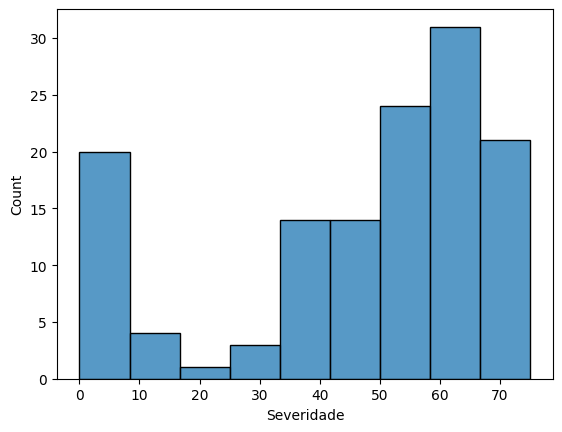

In [7]:
sns.histplot(data=dados, x='Severidade');

Escalas bem diferentes nos indices, muita variacao. Saindo de 0.X ate XXXXX.
E como nao possuem outliers preocupantes, com visto no describe acima, sera usado StandardScaler() posteriormente.

## Feature Engineering

Para termos mais infomacoes com nosso dados, iremso criar 3 novas variaveis, para cada indice.
1. A diferenca entre dia 01 e dia 08 - A semana inicial.
2. A diferenca entre dia 08 e dia 28 - Ultimos vinte dias.
3. A diferenca entre dia 01 e dia 28 - Como comecou e como terminou.

NAo sera usado dia 04, para a criacao de novas variaveis, pois tem uma pequena diferanca de dias.

Variação entre o dia 1 e o dia 8

* NDVI_d08_d01 = NDVI_d08 - NDVI_d01
* SAVI_d08_d01 = SAVI_d08 - SAVI_d01
* GNDVI_d08_d01 = GNDVI_d08 - GNDVI_d01
* MCARI1_d08_d01 = MCARI1_d08 - MCARI1_d01
* SR_d08_d01 = SR_d08 - SR_d01



In [8]:
dados['Diff_NDVI_d08_d01'] =  dados['NDVI_d08'] - dados['NDVI_d01']
dados['Diff_SAVI_d08_d01'] =  dados['SAVI_d08'] - dados['SAVI_d01']
dados['Diff_GNDVI_d08_d01'] =  dados['GNDVI_d08'] - dados['GNDVI_d01']
dados['Diff_MCARI1_d08_d01'] =  dados['MCARI1_d08'] - dados['MCARI1_d01']
dados['Diff_SR_d08_d01'] =  dados['SR_d08'] - dados['SR_d01']


Variação entre o dia 8 e o dia 28

* NDVI_d28_d08 = NDVI_d28 - NDVI_d08
* SAVI_d28_d08 = SAVI_d28 - SAVI_d08
* GNDVI_d28_d08 = GNDVI_d28 - GNDVI_d08
* MCARI1_d28_d08 = MCARI1_d28 - MCARI1_d08
* SR_d28_d08 = SR_d28 - SR_d08


In [9]:
dados['Diff_NDVI_d28_d08'] =  dados['NDVI_d28'] - dados['NDVI_d08']
dados['Diff_SAVI_d28_d08'] =  dados['SAVI_d28'] - dados['SAVI_d08']
dados['Diff_GNDVI_d28_d08'] =  dados['GNDVI_d28'] - dados['GNDVI_d08']
dados['Diff_MCARI1_d28_d08'] =  dados['MCARI1_d28'] - dados['MCARI1_d08']
dados['Diff_SR_d28_d08'] =  dados['SR_d28'] - dados['SR_d08']

Variação entre o dia 1 e o dia 28

* NDVI_d28_d01 = NDVI_d28 - NDVI_d01
* SAVI_d28_d01 = SAVI_d28 - SAVI_d01
* GNDVI_d28_d01 = GNDVI_d28 - GNDVI_d01
* MCARI1_d28_d01 = MCARI1_d28 - MCARI1_d01
* SR_d28_d01 = SR_d28 - SR_d01

In [10]:
dados['Diff_NDVI_d28_d01'] =  dados['NDVI_d28'] - dados['NDVI_d01']
dados['Diff_SAVI_d28_d01'] =  dados['SAVI_d28'] - dados['SAVI_d01']
dados['Diff_GNDVI_d28_d01'] =  dados['GNDVI_d28'] - dados['GNDVI_d01']
dados['Diff_MCARI1_d28_d01'] =  dados['MCARI1_d28'] - dados['MCARI1_d01']
dados['Diff_SR_d28_d01'] =  dados['SR_d28'] - dados['SR_d01']

In [11]:
dados.columns

Index(['id', 'NDVI_d28', 'SAVI_d28', 'GNDVI_d28', 'MCARI1_d28', 'SR_d28',
       'NDVI_d01', 'SAVI_d01', 'GNDVI_d01', 'MCARI1_d01', 'SR_d01', 'NDVI_d04',
       'SAVI_d04', 'GNDVI_d04', 'MCARI1_d04', 'SR_d04', 'NDVI_d08', 'SAVI_d08',
       'GNDVI_d08', 'MCARI1_d08', 'SR_d08', 'Severidade', 'Diff_NDVI_d08_d01',
       'Diff_SAVI_d08_d01', 'Diff_GNDVI_d08_d01', 'Diff_MCARI1_d08_d01',
       'Diff_SR_d08_d01', 'Diff_NDVI_d28_d08', 'Diff_SAVI_d28_d08',
       'Diff_GNDVI_d28_d08', 'Diff_MCARI1_d28_d08', 'Diff_SR_d28_d08',
       'Diff_NDVI_d28_d01', 'Diff_SAVI_d28_d01', 'Diff_GNDVI_d28_d01',
       'Diff_MCARI1_d28_d01', 'Diff_SR_d28_d01'],
      dtype='object')

In [12]:
dados.shape

(132, 37)

In [13]:
dados.isnull().sum().sum()

0

## Escalonando

In [14]:
X = dados.drop(columns=['id', 'Severidade'])
y = dados['Severidade']

In [15]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

X_sc = pd.DataFrame(X_sc, columns=X.columns)

In [16]:
X_sc

,NDVI_d28,SAVI_d28,GNDVI_d28,MCARI1_d28,SR_d28,NDVI_d01,SAVI_d01,GNDVI_d01,MCARI1_d01,SR_d01,...,Diff_NDVI_d28_d08,Diff_SAVI_d28_d08,Diff_GNDVI_d28_d08,Diff_MCARI1_d28_d08,Diff_SR_d28_d08,Diff_NDVI_d28_d01,Diff_SAVI_d28_d01,Diff_GNDVI_d28_d01,Diff_MCARI1_d28_d01,Diff_SR_d28_d01
0,0.750961,0.751051,0.900545,1.791985,1.003022,0.634275,0.634289,0.596037,0.702527,0.677168,...,0.461911,0.461955,0.561910,0.687973,0.821514,0.446146,0.446329,1.465828,0.158022,1.090863
1,0.261546,0.261600,0.411708,0.820577,0.282255,0.110644,0.110612,0.242735,-0.247398,0.077376,...,0.606042,0.606117,0.593032,1.031549,0.574275,0.395171,0.395366,0.769051,0.805902,0.494476
2,0.724512,0.724544,0.704624,1.094241,0.928254,0.709177,0.709254,0.426510,2.137737,0.994381,...,0.523618,0.523600,0.783901,0.203908,0.821463,0.218963,0.218872,1.279386,-2.106023,0.400410
3,-0.045039,-0.045046,0.004740,-0.194944,0.007701,0.040642,0.040697,-0.069611,0.923830,0.063167,...,-0.137307,-0.137315,-0.057095,-0.131441,-0.007249,-0.197870,-0.198003,0.249507,-1.306482,-0.087657
4,-0.058165,-0.058118,-0.099538,0.500864,-0.228990,0.352047,0.352096,-0.009719,0.927692,0.302597,...,-1.466744,-1.466795,-1.508456,-2.298028,-1.488608,-0.906987,-0.906961,-0.348682,-0.898493,-1.006456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,-0.224955,-0.224987,0.294130,-0.539439,-0.232284,0.089280,0.089309,0.553978,0.497628,0.064430,...,-0.242566,-0.242541,-0.296556,0.121631,-0.145994,-0.740997,-0.741121,-0.715444,-0.961582,-0.619162
128,-2.674903,-2.674784,-2.717851,-1.232834,-2.548301,-2.201820,-2.201817,-2.575589,-1.637029,-2.204705,...,-2.215986,-2.215893,-2.364235,-1.247033,-2.137519,-1.714098,-1.713792,-1.842246,1.378374,-1.969192
129,-2.151808,-2.151741,-2.226424,-1.280537,-2.017270,-1.562874,-1.562844,-2.060648,-0.946487,-1.605881,...,-1.642190,-1.642169,-1.482720,-1.232385,-1.601117,-1.832027,-1.831900,-1.672789,0.459981,-1.789767
130,-3.651098,-3.651011,-3.374127,-2.457238,-3.035038,-3.193952,-3.193884,-3.060587,-1.641021,-2.801254,...,-2.487958,-2.487891,-2.239725,-1.504726,-2.156936,-1.929534,-1.929444,-2.742187,0.656830,-2.054675


## Dividindo os dados

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_sc, y , test_size=0.2, shuffle=True, random_state=42)

## Baseline

In [18]:
model = LinearRegression()

r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")

print(f"R2 Medio: {r2_scores.mean():.4f} ± DP: {r2_scores.std():.4f}")

R2 Medio: 0.8721 ± DP: 0.0654


## Feature Importance

In [19]:
model.fit(X_train, y_train)

#df com os coeficientes
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": np.abs(model.coef_)
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                Feature    Importance
15             NDVI_d08  85395.918185
16             SAVI_d08  85388.619529
10             NDVI_d04  78129.267376
11             SAVI_d04  78119.628521
0              NDVI_d28  62645.555250
1              SAVI_d28  62643.111082
5              NDVI_d01  54767.070322
6              SAVI_d01  54760.227084
31    Diff_SAVI_d28_d01  33191.075864
30    Diff_NDVI_d28_d01  33182.589242
21    Diff_SAVI_d08_d01  30785.281465
20    Diff_NDVI_d08_d01  30784.587905
25    Diff_NDVI_d28_d08  14460.508024
26    Diff_SAVI_d28_d08  14458.388157
19               SR_d08     19.819074
13           MCARI1_d04     15.603476
3            MCARI1_d28     14.335634
18           MCARI1_d08     11.838890
9                SR_d01     11.589057
14               SR_d04     10.243520
24      Diff_SR_d08_d01      8.099647
4                SR_d28      7.469428
29      Diff_SR_d28_d08      7.002092
23  Diff_MCARI1_d08_d01      4.624853
17            GNDVI_d08      4.309042
22   Diff_GN

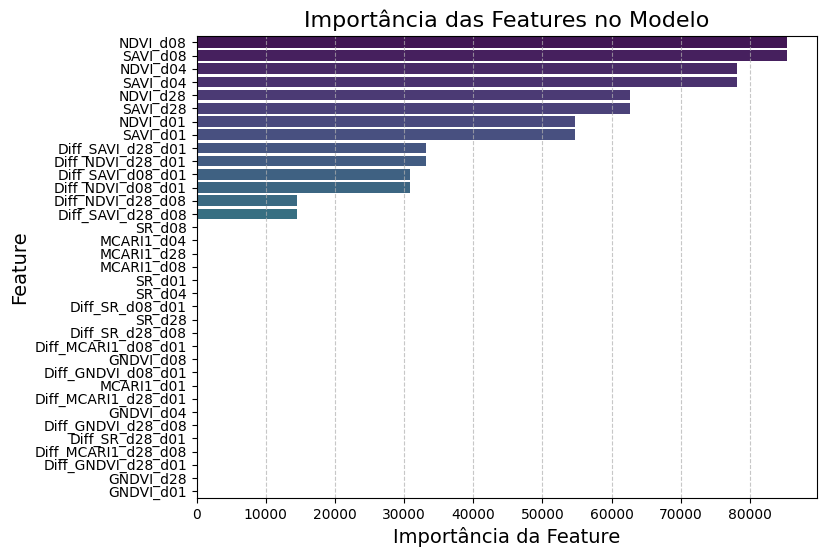

In [20]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance.sort_values(by="Importance", ascending=False),
    x="Importance",
    y="Feature",
    palette="viridis",
    hue="Feature"
)
#DEixando bonitinho
plt.xlabel("Importância da Feature", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title("Importância das Features no Modelo", fontsize=16)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


COmo podemos ver, claramente as variaveis NDVI e SAVI, com seus respectivos dias 04, 08 e 28, dominam o ganho de informacao. E como elas tem uma imprtancia muito boa para o modelo, as variaveis derivadas delas tambem tem um ganho de informacao. Apesar que ainda se faz necessario descobrir se este ganho nao e apenas auto correlacao. Iremos selecionar as varivaies de acordo com o grafico, ou seja do topo ate SAVI_d01

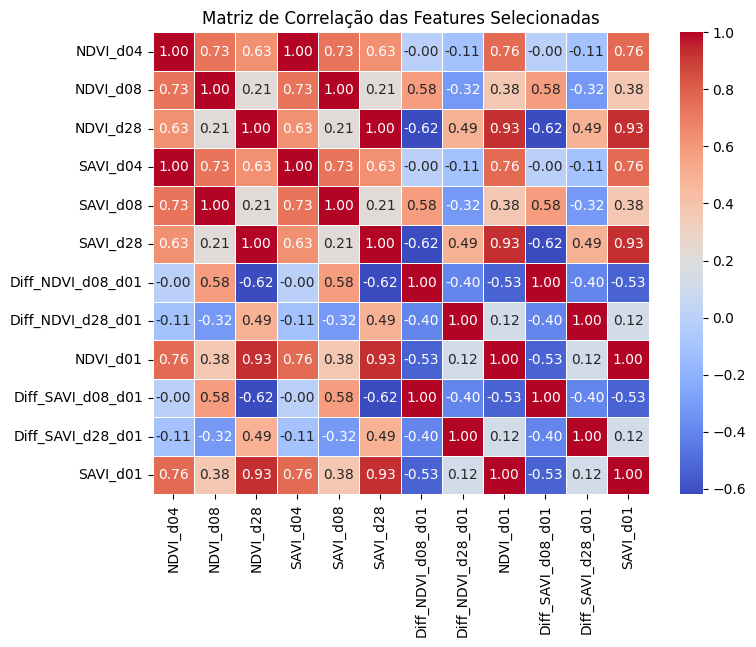

In [21]:
features_selecionadas = [
    "NDVI_d04", "NDVI_d08", "NDVI_d28", "SAVI_d04", "SAVI_d08", "SAVI_d28",
    "Diff_NDVI_d08_d01", "Diff_NDVI_d28_d01", "NDVI_d01", "Diff_SAVI_d08_d01",
    "Diff_SAVI_d28_d01", "SAVI_d01"
]

X_train_importance = X_train[features_selecionadas]
corr_matrix = X_train_importance.corr() #  a matriz de correlacao

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlação das Features Selecionadas")
plt.show()


In [22]:
def calcular_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# Removendo colunas altamente correlacionadas (VIF > 5)
def remover_multicolinearidade(df, threshold=5):
    vif_df = calcular_vif(df)
    while vif_df["VIF"].max() > threshold:
        feature_a_remover = vif_df.loc[vif_df["VIF"].idxmax(), "Feature"]
        df = df.drop(columns=[feature_a_remover])
        vif_df = calcular_vif(df)
    return df, vif_df

X_train_reduzido, vif_resultado = remover_multicolinearidade(X_train_importance)


print("Features selecionadas após remoção da multicolinearidade:")
print(X_train_reduzido.columns)

scores = cross_val_score(model, X_train_reduzido, y_train, cv=5, scoring='r2') #Usando o mesmo modelo da validacao acima, para comparacao diereta
print(f"Novo R² médio na validação cruzada: {np.mean(scores):.4f}")


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Features selecionadas após remoção da multicolinearidade:
Index(['SAVI_d04', 'Diff_NDVI_d08_d01', 'Diff_SAVI_d28_d01'], dtype='object')
Novo R² médio na validação cruzada: 0.8186


Aqui temso dois pontos:
1. VIF com valores infinitos
2. A performace do modelo decaiu bastante

Vamos testar outro metodo: SelectKBest()

In [23]:
for k in range(1, 36):
  selector = SelectKBest(score_func=f_regression, k=k)
  X_new = selector.fit_transform(X_train, y_train)


  selected_features = X_train.columns[selector.get_support()] #features foram selecionadas
  print(f"{k} Features selecionadas:", list(selected_features))

  model = RandomForestRegressor(random_state=42)
  scores = cross_val_score(model, X_new, y_train, cv=5, scoring="r2")

  print("Novo R² médio na validação cruzada:", scores.mean())

1 Features selecionadas: ['Diff_GNDVI_d08_d01']
Novo R² médio na validação cruzada: 0.6481221554870535
2 Features selecionadas: ['MCARI1_d08', 'Diff_GNDVI_d08_d01']
Novo R² médio na validação cruzada: 0.8322791708736872
3 Features selecionadas: ['MCARI1_d08', 'SR_d08', 'Diff_GNDVI_d08_d01']
Novo R² médio na validação cruzada: 0.8605436435683458
4 Features selecionadas: ['MCARI1_d08', 'SR_d08', 'Diff_GNDVI_d08_d01', 'Diff_GNDVI_d28_d08']
Novo R² médio na validação cruzada: 0.8612810391933661
5 Features selecionadas: ['SAVI_d08', 'MCARI1_d08', 'SR_d08', 'Diff_GNDVI_d08_d01', 'Diff_GNDVI_d28_d08']
Novo R² médio na validação cruzada: 0.8613787952733875
6 Features selecionadas: ['NDVI_d08', 'SAVI_d08', 'MCARI1_d08', 'SR_d08', 'Diff_GNDVI_d08_d01', 'Diff_GNDVI_d28_d08']
Novo R² médio na validação cruzada: 0.8610550623816323
7 Features selecionadas: ['NDVI_d08', 'SAVI_d08', 'MCARI1_d08', 'SR_d08', 'Diff_GNDVI_d08_d01', 'Diff_GNDVI_d28_d08', 'Diff_MCARI1_d28_d08']
Novo R² médio na validação cr

MEsmo que de maineira poluida, dar pra ver que com 29 variaveis o modelos apresenta maior r2.

In [27]:
selector = SelectKBest(score_func=f_regression, k=29) # K escolhido pelo SelectKBest
X_train_best = selector.fit_transform(X_train, y_train)
X_test_best = selector.transform(X_test)  # Aplicar a mesma transformacao nos dados de teste

##Nomes das 29 variaveis
selected_features = X_train.columns[selector.get_support()]
print("Variáveis selecionadas:", list(selected_features))

Variáveis selecionadas: ['NDVI_d28', 'SAVI_d28', 'GNDVI_d28', 'SR_d28', 'MCARI1_d01', 'NDVI_d04', 'SAVI_d04', 'MCARI1_d04', 'SR_d04', 'NDVI_d08', 'SAVI_d08', 'GNDVI_d08', 'MCARI1_d08', 'SR_d08', 'Diff_NDVI_d08_d01', 'Diff_SAVI_d08_d01', 'Diff_GNDVI_d08_d01', 'Diff_MCARI1_d08_d01', 'Diff_SR_d08_d01', 'Diff_NDVI_d28_d08', 'Diff_SAVI_d28_d08', 'Diff_GNDVI_d28_d08', 'Diff_MCARI1_d28_d08', 'Diff_SR_d28_d08', 'Diff_NDVI_d28_d01', 'Diff_SAVI_d28_d01', 'Diff_GNDVI_d28_d01', 'Diff_MCARI1_d28_d01', 'Diff_SR_d28_d01']


In [28]:
model = RandomForestRegressor(random_state=42)
scores = cross_val_score(model, X_train[selected_features], y_train, cv=5, scoring="r2")

print("Novo R² médio na validação cruzada k=29:", scores.mean())

Novo R² médio na validação cruzada k=29: 0.8769153528587879


## EScolhendo modelos

In [29]:
X_train[selected_features]

,NDVI_d28,SAVI_d28,GNDVI_d28,SR_d28,MCARI1_d01,NDVI_d04,SAVI_d04,MCARI1_d04,SR_d04,NDVI_d08,...,Diff_NDVI_d28_d08,Diff_SAVI_d28_d08,Diff_GNDVI_d28_d08,Diff_MCARI1_d28_d08,Diff_SR_d28_d08,Diff_NDVI_d28_d01,Diff_SAVI_d28_d01,Diff_GNDVI_d28_d01,Diff_MCARI1_d28_d01,Diff_SR_d28_d01
95,0.742053,0.742019,1.158003,0.706134,0.789696,-0.430735,-0.430892,-1.103199,-0.579343,-0.632859,...,1.076796,1.076874,1.151941,1.374153,1.017063,0.174293,0.174165,1.030888,-0.954910,0.317569
96,-0.692593,-0.692565,-0.389343,-0.847080,-1.294331,-0.675983,-0.676009,-0.535039,-0.738811,-0.540356,...,-0.146579,-0.146527,-0.022744,0.360028,-0.306800,0.155213,0.155415,0.407071,1.455716,-0.290538
0,0.750961,0.751051,0.900545,1.003022,0.702527,1.711128,1.711370,3.104725,1.784878,0.186707,...,0.461911,0.461955,0.561910,0.687973,0.821514,0.446146,0.446329,1.465828,0.158022,1.090863
12,0.756363,0.756401,0.914584,0.861204,0.716279,1.790484,1.790611,2.187795,1.870094,0.432369,...,0.279798,0.279765,0.247618,-0.151786,0.541007,-0.564823,-0.564733,-0.100836,-0.284206,-0.045730
126,-0.489180,-0.489184,-0.092379,-0.439471,0.173261,-0.674657,-0.674555,-0.139606,-0.694674,-0.699869,...,0.137993,0.138009,0.238183,0.446253,0.072481,-0.498195,-0.498270,-0.288089,-0.509597,-0.413827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.222146,0.222117,0.624432,0.154351,0.720236,-0.839561,-0.839701,-1.310957,-0.816270,-0.256488,...,0.373233,0.373256,0.290480,0.555870,0.368009,-0.689522,-0.689610,-0.537117,-1.063601,-0.664422
106,0.649822,0.649818,0.086609,0.693854,0.344491,-0.028835,-0.028879,-0.233152,-0.173933,-0.646504,...,1.013017,1.013037,0.723377,1.146506,1.007404,0.763692,0.763695,-0.341675,-0.055598,0.966680
14,0.602406,0.602419,0.549072,0.736015,-0.103071,0.888560,0.888508,0.310039,0.938174,0.067246,...,0.433173,0.433159,0.123188,0.348799,0.620087,0.819296,0.819378,0.290220,0.518347,1.029877
92,-0.019657,-0.019588,0.651668,-0.022084,-0.487722,0.593554,0.593575,0.388843,0.521864,0.041399,...,-0.047222,-0.047183,-0.037220,0.404543,0.057055,0.259992,0.260174,1.635034,0.985519,0.197017


In [30]:
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

def evaluate_model(model, X, y):
    r2 = np.mean(cross_val_score(model, X, y, cv=5, scoring='r2'))
    rmse = np.mean(np.sqrt(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')))
    mae = np.mean(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error'))
    return r2, rmse, mae

results = {}
for name, model in models.items():
    r2 = evaluate_model(model, X_train[selected_features], y_train)
    results[name] = {'R²': r2}

results_df = pd.DataFrame(results).T
print(results_df.sort_values(by='R²', ascending=False))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.085e+01, tolerance: 3.952e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.085e+01, tolerance: 3.952e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.085e+01, tolerance: 3.952e

                        R²
KNN               0.914067
Random Forest     0.876915
Lasso Regression  0.875109
Ridge Regression  0.871947
XGBoost           0.852641
SVR               0.387964


Usaremos esta etapa para excluir os modelos que nao fazem sentido, logo excluiremos o SVR. Ja que os demais modelos, fora o XGBOOst, ultrapassaram o base line. O XGBoost sera levado em conta, pois pode se beneficiar muito na escolha certa dos hyperparametros.

## Buscando Hyperparametros com GridSearchCV

In [32]:
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, rf_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train[selected_features], y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_rf = {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50} #0.8799293977838059

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
0.8799293977838059


In [33]:
ridge_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge = Ridge(random_state=42)
grid_search_ridge = GridSearchCV(ridge,ridge_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_ridge.fit(X_train[selected_features], y_train)

print(grid_search_ridge.best_params_)
print(grid_search_ridge.best_score_)

best_ridge = {'alpha': 0.01} #0.8773389061312923

{'alpha': 0.01}
0.8773389061312923


In [34]:
lasso_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
    'max_iter': [5000, 7000, 10000, 15000]
}
lasso = Lasso(random_state=42)
grid_search_lasso = GridSearchCV(lasso, lasso_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_lasso.fit(X_train[selected_features], y_train)

print(grid_search_lasso.best_params_)
print(grid_search_lasso.best_score_)

best_lasso = {'alpha': 0.001, 'max_iter': 7000} #0.8771607864760191

{'alpha': 0.001, 'max_iter': 7000}
0.8771607864760191


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.735e+02, tolerance: 5.167e+00
  model = cd_fast.enet_coordinate_descent(


In [35]:
xgb_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}
xgb = XGBRegressor(random_state=42)
grid_search_xgb = GridSearchCV(xgb, xgb_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_xgb.fit(X_train[selected_features], y_train)

print(grid_search_xgb.best_params_)
print(grid_search_xgb.best_score_)

best_xgb = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8} #0.8917714797809296

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
0.8917714797809296


In [36]:
knn_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn = KNeighborsRegressor()
grid_search_knn = GridSearchCV(knn, knn_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_knn.fit(X_train[selected_features], y_train)

print(grid_search_knn.best_params_)
print(grid_search_knn.best_score_)

best_knn = {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'} #0.9140674086593515

{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
0.9140674086593515


O KNN continua sendo o melhor modelo, alcançando R² = 0.9141, ou seja, ele explica cerca de 91,4% da variação dos dados.
✅ O XGBoost melhorou bastante e agora tem R² = 0.8918, sendo um modelo bastante competitivo.
✅ Random Forest, Ridge e Lasso ficaram bem próximos, na faixa de 0.877 a 0.879.

## Validando os modelos com melhores parametros

In [37]:
models = {
    "KNN": KNeighborsRegressor(metric= 'euclidean', n_neighbors= 5, weights= 'uniform'),  # Melhor modelo treinado
    "XGBoost": XGBRegressor(random_state=42, colsample_bytree= 0.8, learning_rate= 0.1, max_depth= 3, n_estimators= 500, subsample= 0.8),
    "Random Forest": RandomForestRegressor(random_state=42, max_depth= None, min_samples_leaf= 1, min_samples_split= 2, n_estimators= 50),
    "Ridge": Ridge(random_state=42, alpha=0.01),
    "Lasso": Lasso(random_state=42, alpha=0.001, max_iter= 7000)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')  # k=5 folds
    print(f"{name}: R² médio = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

KNN: R² médio = 0.9145 ± 0.0195
XGBoost: R² médio = 0.8929 ± 0.0306
Random Forest: R² médio = 0.8735 ± 0.0339
Ridge: R² médio = 0.8749 ± 0.0726
Lasso: R² médio = 0.8748 ± 0.0724


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.605e+02, tolerance: 4.144e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.524e+02, tolerance: 3.952e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.371e+02, tolerance: 4.267e

Dos modelos acima, os dois melhores foram o KNN e logo apos o XGBoost, vamos usar os dois nos dados de teste para decidir, e usando as metricas RMSE e MAE

In [38]:
knn = KNeighborsRegressor(metric='euclidean', n_neighbors=5, weights='uniform')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

xgb_model = XGBRegressor(colsample_bytree=0.8, learning_rate=0.1, max_depth=3,
                             n_estimators=500, subsample=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

def avaliar_modelo(y_true, y_pred, nome):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n {nome}")
    print(f"R²: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

avaliar_modelo(y_test, y_pred_knn, "KNN")
avaliar_modelo(y_test, y_pred_xgb, "XGBoost")


 KNN
R²: 0.9077
RMSE: 7.7095
MAE: 5.6781

 XGBoost
R²: 0.9077
RMSE: 7.7104
MAE: 5.7471


Considerando os resultados acima, vemos que os dois modelos performaram muito bem e foram muito semelhantes. Como o conjunto e pequemo e nao temos necessidade da explicabilidade, iremos usar o KNN. Porem, antes, como os doismodelos foram muito semelhantes, vamos realizar um ensemble dos modelos, para verificar se existe algum melhoria ao usar os dois modelos juntos.

## Ensemble

In [40]:
def avaliar_modelos(knn, xgb, X_test, y_test):

    y_pred_knn = knn.predict(X_test)
    y_pred_xgb = xgb.predict(X_test)

    y_pred_ensemble = (y_pred_knn + y_pred_xgb) / 2

    resultados = pd.DataFrame({
        'Modelo': ['KNN', 'XGBoost', 'Ensemble (Média)'],
        'R²': [
            r2_score(y_test, y_pred_knn),
            r2_score(y_test, y_pred_xgb),
            r2_score(y_test, y_pred_ensemble)
        ],
        'RMSE': [
            root_mean_squared_error(y_test, y_pred_knn),
            root_mean_squared_error(y_test, y_pred_xgb),
            root_mean_squared_error(y_test, y_pred_ensemble)
        ],
        'MAE': [
            mean_absolute_error(y_test, y_pred_knn),
            mean_absolute_error(y_test, y_pred_xgb),
            mean_absolute_error(y_test, y_pred_ensemble)
        ]
    })

    return resultados

resultados = avaliar_modelos(knn, xgb, X_test, y_test)
print(resultados)

             Modelo        R²      RMSE       MAE
0               KNN  0.907726  7.709506  5.678148
1           XGBoost  0.907704  7.710442  5.747139
2  Ensemble (Média)  0.918903  7.227551  5.414981


O ensemble simples se mostrou superior aos modelos usados de maneira isolado.

## Conclusao

Os tres modelos finais tiveram um performace exelente nos dados de teste. Sendo a juncao dos dois modelos isolados o melhor, e mesmo sendo um ganho de 1% no r2 e +- 0.5 no RMSE e nao sera a escolha final do nosso projeto, pois na realidade temos um conjunto simples, que o modelo Knn, sendo mais simples, ja foi capaz de ter uma performace melhor. Ainda mais considerando como limitacao o fato de poucos registros por features impactarem no XGBoost, torna ainda mais clara a escolha do modelo simples para resolver um problema simples.